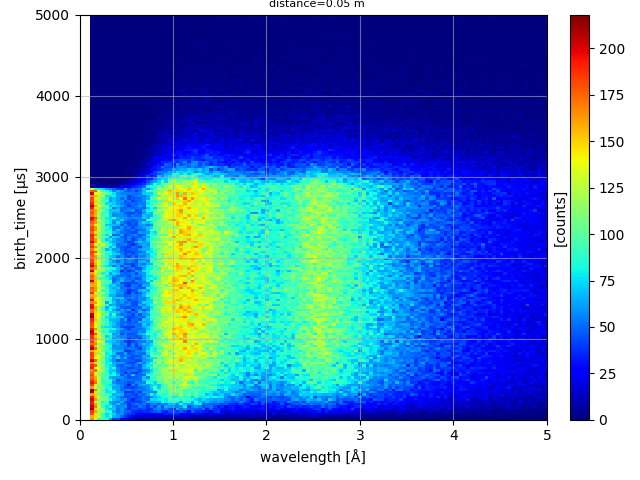

In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
import scipp as sc
import tof

source = tof.Source(facility="ess-trex", neutrons=1_000_000)
da = source.data.squeeze()

fig, ax = plt.subplots()
p = da.hist(birth_time=200, wavelength=500).plot(cmap="jet", ax=ax)
ax.set_title(str(source), fontsize=8)
ax.set_xlim([0, 5])
ax.set_ylim([0, 5000])
ax.grid(alpha=0.6)

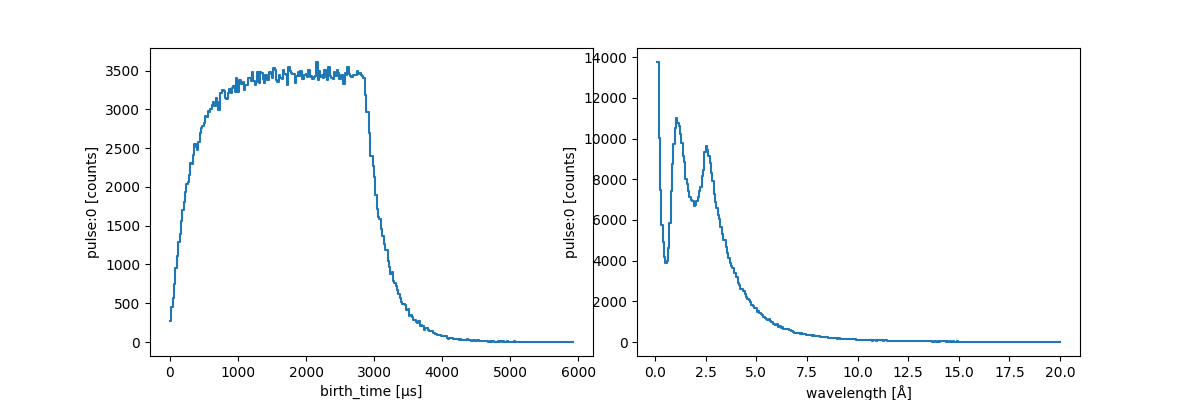

In [ ]:
%matplotlib widget
source = tof.Source(facility="ess-trex", neutrons=500_000)
source.plot()


In [3]:
from drtrex.components.source import Source
from drtrex.instrument import Instrument

central_wavelength = sc.scalar(1.5, unit="Å")
rrm: int = 8  # repetition rate multiplication factor
T_OFFSET = sc.scalar(1.7, unit="ms")
trex = Instrument(wavelength=central_wavelength, rrm=rrm, t_offset=T_OFFSET)
mask = trex.mask_from_choppers("Monochromatic Chopper 2")
# mask = trex.mask_from_chopper("Bandwidth Chopper 2")

source = Source(facility="ess", neutrons=1_000_000)
source.apply_mask(mask)
print(source.data)

<scipp.DataArray>
Dimensions: Sizes[pulse:1, event:3715, ]
Coordinates:
* birth_time                float64            [µs]  (pulse, event)  [1526.35, 605.414, ..., 776.899, 2107.97]
* distance                  float64              [m]  ()  0.05
* eto                       float64            [µs]  (pulse, event)  [1526.35, 605.414, ..., 776.899, 2107.97]
* id                          int64        <no unit>  (pulse, event)  [528, 612, ..., 999895, 999966]
* speed                     float64            [m/s]  (pulse, event)  [2037.53, 2015.47, ..., 2597.83, 2316.74]
* toa                       float64            [µs]  (pulse, event)  [1526.35, 605.414, ..., 776.899, 2107.97]
* wavelength                float64             [Å]  (pulse, event)  [1.94158, 1.96284, ..., 1.52282, 1.70759]
Data:
                            float64         [counts]  (pulse, event)  [1, 1, ..., 1, 1]




In [4]:
flux = trex.estimate_flux()
flux

<scipp.Variable> (rrm: 7)      int64         [counts]  [198, 872, ..., 535, 202]

In [5]:
import tof
import scipp as sc
import plopp as pp
instruments = ["cspec", "bifrost", "miracles", "trex","vespa", "tbl"]

histograms = {}
wavelength_bins = sc.linspace(start=0, stop=4., num=100, unit='angstrom', dim='wavelength')
for inst in instruments:
    src = tof.Source(facility=f'ess-{inst}')
    histograms[inst] = src.data.hist(wavelength = wavelength_bins)


plot = pp.plot(histograms, grid=True, title='ESS sources', figsize=(10, 5))
plot.ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.05), ncol=5)
plot

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…